# [1교시]

### Fine-tuning 패러다임의 한계
#### 기존 방식 (딥러닝 이전/초기 NLP 방식)
- 각 태스크마다 **별도의 모델이나 규칙을 설계하고 학습**
- 자연어처리: 감성분석, 개체명인식, 질의응답 등 각각 다른 모델 필요
- 비용: 매우 높음 (데이터 수집, 레이블링, 학습 시간 등)

#### Early Transfer Learning (2000s-2010s)
- 하나의 큰 모델을 먼저 학습한 후, 특정 태스크에 맞게 조정
- 예: ImageNet에서 학습한 CNN을 다른 이미지 분류 태스크에 전이
- 장점: 데이터가 적어도 괜찮은 성능 달성 가능
- 한계: 여전히 **각 태스크마다 미세조정(Fine-tuning) 필요**

#### BERT의 등장 (2018)
- 양방향 문맥을 고려한 Pre-training
- 많은 NLP 태스크에서 SOTA(State-of-the-Art) 달성
- 하지만 여전히 **Fine-tuning 필수**: 새로운 태스크가 나타날 때마다 모델을 다시 학습

### 2. GPT 계열의 역사: Fine-tuning 없는 세상으로

#### GPT-1 (2018)
- 파라미터: 1.17억 개
- 특징: 단방향 언어 모델(Causal LM) + Pre-training + Fine-tuning
- 의의: 대규모 언어 모델 사전학습 후 태스크별 Fine-tuning이 효과적임을 보여줌

#### GPT-2 (2019)
- 파라미터: 1.5억~15억 개
- 놀라운 발견: **Fine-tuning 없이도** 일부 태스크를 프롬프트 형태로 수행할 가능성을 보여줌
- 예: 생성된 텍스트의 품질 급증, 요약, 번역 등을 프롬프트만으로 수행

#### GPT-3 (2020) ← 게임 체인저
- 파라미터: **1,750억 개** (GPT-2의 100배 이상)
- 가장 중요한 발견: **Zero-shot, Few-shot Learning의 실현**
  - Zero-shot: 예시 없이 인스트럭션만으로 태스크 수행
  - Few-shot: 소수의 예시만으로 새로운 패턴 학습
- 단계별 성능 향상: 규모가 커지면서 일부 능력이 비선형적으로 나타나는 현상이 관찰됨

#### GPT-3.5 → GPT-4 (2022~2023)
- 파라미터: 공개되지 않음 (GPT-3보다 훨씬 큰 규모로 추정)
- Instruction Tuning/RLHF 계열 기법이 본격적으로 활용되며 지시를 따르는 능력 대폭 향상
- ChatGPT의 성공: 다양한 산업에서 LLM 도입 가속화

### 3. 규모가 커지며 나타나는 새로운 능력의 본질

#### 정의
> "모델 규모가 커지면서 특정 과제에서 성능이 비선형적으로 크게 향상되는 현상"

#### 특징
1. **연속적 증가가 아니라 단계적 도약**
   - 모델이 작을 때: 증가해도 능력 변화 미미
   - 임계값 넘음: 갑자기 새로운 능력 출현

2. **Few-shot In-context Learning**
   - 작은 모델: 몇 가지 예시를 줘도 패턴을 못 잡음
   - 큰 모델: 2~3개 예시만으로도 패턴 학습 가능

3. **복잡한 추론 능력**
   - 작은 모델: 단순 패턴 매칭 수준에 머무르는 경우가 많음
   - 큰 모델: 다단계 논리 추론 가능

#### 예시
- **논리 퀴즈**: "철수는 영희보다 키가 크고, 영희는 민준보다 키가 크다. 셋 중 누가 가장 키가 클까?"
  - 작은 모델: 무작위 답변
  - 큰 모델: 논리적 추론으로 "철수"라고 답변

### Pre-training의 첫번째 관문
- 데이터의 역할 : 다다익선
- 데이터처리 파이프라인
    - 원본 텍스트 데이터
        - 1단계 : 필터링(스팸, 저품질 제거)
        - 2단계 : 중복제거
        - 3단계 : 정규화
        - 4단계 : 토큰화
    - 훈련가능한 데이터
- 토큰화 : 텍스트를 모델이 이해할 수 있는 정수 시퀀스로 변환하는 과정
    - 1. 전처리
        - 공백표준화
        - 특수문자처리
        - 케이스통일
    - 2. 어휘선택
        - character-level : 문자단위(너무 길어짐)
        - Word-level : 단어단위(어휘크기 폭증)
        - Subword-level : n-gram(GPT 계열) --> 가장 효율적
    - 3. 어휘사전
        - 가장 자주 나타나는 시퀀스 학습(playing = play + ing)
- Byte-Pair Encoding(BPE)
    - 1. 초기 단어 분해
        hello word -> [h, e, l ....]
    - 2. 가장 빈번한 바이트 쌍 병합
        반복 1 : ('l', 'l') -> 'll'
        반복 2 : ('h', 'e') -> 'he'
        반복 3 : ('w', 'o') -> 'wo'
    - 3. 병합규칙 저장
        merge_rules = {
            ('l','l') : 'B1'
            ...
        }
    - 4. 어휘생성(단어사전 vocabulary)
        vocab = ['h', 'e',,, 'll', 'he']

#### BPE의 장점
1. **어휘 크기 조절 가능**: 50K ~ 200K 범위에서 유연함
2. **미지의 단어 처리**: OOV(Out-of-Vocabulary) 거의 발생하지 않음
3. **효율성**: 긴 문장을 적정 길이로 압축

### 4. 토큰화가 성능에 미치는 영향

#### 예시 1: "PlayGround"
- **나쁜 토큰화**: ['P', 'l', 'a', 'y', 'G', 'r', 'o', 'u', 'n', 'd'] (10개)
- **좋은 토큰화**: ['Play', 'Ground'] (2개)
- **영향**: 입력 길이 감소 → 모델이 더 넓은 맥락 볼 수 있음

#### 예시 2: 다국어 처리
- 영어: 효율적 토큰화 가능
- 한국어/중국어: 문자 단위에 가까워야 함 (언어별 토크나이저 필요)

# [2교시]

In [1]:
from collections import Counter, defaultdict
import re
from typing import List, Dict, Tuple
import pandas as pd
import matplotlib.pyplot as plt
# 재현성
import random
random.seed(42)

In [2]:
# 작은 말뭉치
corpus = [
    "hello world hello there",
    "hello beautiful world",
    "the quick brown fox",
    "the lazy dog",
    "hello hello",
    "world peace"
]
class BPETokenizer:
    '''
    BPE(Byte-Pair-Encoding)

    작동:
    1. 텍스트를 문자 단위로 분해
    2. 가장 자주 나타나는 인접한 쌍(pair)을 찾음
    3. 그 쌍을 하나의 새 토큰으로 병합
    4. 2-3을 반복해서 어휘크기를 조절
    '''
    def __init__(self):
        self.word_freqs = defaultdict(int) # 단어빈도
        self.merges = {}  # 병합규칙(pair) -> new token
        self.vocab = set() # 현재 어휘
        self.merge_history = []  # 병합과정 기록
    def _build_initial_vocab(self, corpus:List[str]):
        '''step 1 : 텍스트를 단어어로 분해하고 문자 단위로 분리'''
        for text in corpus:
            words = text.split()
            for word in words:
                self.word_freqs[word] += 1
        
        # 초기어휘 : 모든 문자
        for word in self.word_freqs:
            for char in word:
                self.vocab.add(char)
        self.vocab.add('</w>')  # 특수토큰 : 단어 끝을 표시(GPT 스타일)
        return self
    
    def get_stats(self, vocab:Dict[str,int]) -> Dict[Tuple[str,str], int]:
        '''각(pair) 조합의 빈도를 계산'''
        pairs = defaultdict(int)
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols)-1):
                pairs[symbols[i], symbols[i+1]] += freq              
        return pairs
    
    def merge_vocab(self, pair:Tuple[str,str], vocab:Dict[str,int]) -> Dict[str,int]:
        '''특정 pair를 하나의 토큰으로 병합'''
        new_vocab = {}
        bigram =' '.join(pair)
        replacement = ''.join(pair)
        for word in vocab:
            new_word = word.replace(bigram, replacement)
            new_vocab[new_word] = vocab[word]
        return new_vocab
    
    def train(self, corpus: List[str], num_merges: int = 10):
        """BPE 훈련: num_merges 번만큼 반복"""
        self._build_initial_vocab(corpus)
        
        # 초기 vocab dict 생성
        vocab = {}
        for word, freq in self.word_freqs.items():
            #  각 문자 사이에 공백 추가
            vocab[' '.join(word) + ' </w>'] = freq
        
        print(f"[초기 어휘 크기] {len(self.vocab)}")
        print(f"[병합 시작] {num_merges}번 반복\n")
        
        for i in range(num_merges):
            pairs = self.get_stats(vocab)
            
            if not pairs:
                print(f"  반복 {i+1}: 병합 가능한 pair가 없음. 중단.")
                break
            
            best_pair = max(pairs, key=pairs.get)
            best_freq = pairs[best_pair]
            
            # 각 병합 단계 상세 기록
            vocab = self.merge_vocab(best_pair, vocab)
            self.merges[best_pair] = ''.join(best_pair)
            new_token = ''.join(best_pair)
            self.vocab.add(new_token)
            
            merge_record = {
                'iteration': i + 1,
                'pair': f"('{best_pair[0]}', '{best_pair[1]}')",
                'frequency': best_freq,
                'new_token': new_token,
                'vocab_size': len(self.vocab)
            }
            self.merge_history.append(merge_record)
            
            print(f"  반복 {i+1}: {best_pair} → '{new_token}' (빈도: {best_freq})")
        
        print(f"\n[최종 어휘 크기] {len(self.vocab)}")
        return self

In [3]:
tokenizer = BPETokenizer()
tokenizer.train(corpus=corpus, num_merges=10)

[초기 어휘 크기] 23
[병합 시작] 10번 반복

  반복 1: ('h', 'e') → 'he' (빈도: 8)
  반복 2: ('he', 'l') → 'hel' (빈도: 5)
  반복 3: ('hel', 'l') → 'hell' (빈도: 5)
  반복 4: ('hell', 'o') → 'hello' (빈도: 5)
  반복 5: ('hello', '</w>') → 'hello</w>' (빈도: 5)
  반복 6: ('w', 'o') → 'wo' (빈도: 3)
  반복 7: ('wo', 'r') → 'wor' (빈도: 3)
  반복 8: ('wor', 'l') → 'worl' (빈도: 3)
  반복 9: ('worl', 'd') → 'world' (빈도: 3)
  반복 10: ('world', '</w>') → 'world</w>' (빈도: 3)

[최종 어휘 크기] 33


In [4]:
tokenizer.merges

{('h', 'e'): 'he',
 ('he', 'l'): 'hel',
 ('hel', 'l'): 'hell',
 ('hell', 'o'): 'hello',
 ('hello', '</w>'): 'hello</w>',
 ('w', 'o'): 'wo',
 ('wo', 'r'): 'wor',
 ('wor', 'l'): 'worl',
 ('worl', 'd'): 'world',
 ('world', '</w>'): 'world</w>'}

In [5]:
def tokenize_word(word: str, merges: dict, vocab: set) -> List[str]:
    """학습된 merge 규칙을 적용하여 단어 토큰화"""
    # Step 1: 문자 단위로 분해
    chars = list(word) + ['</w>']

    # Step 2: merge 규칙을 순서대로 적용
    for pair, new_token in merges.items():
        while True:
            found = False
            for j in range(len(chars) - 1):
                if chars[j] == pair[0] and chars[j + 1] == pair[1]:
                    chars[j:j + 2] = [new_token]
                    found = True
                    break
            if not found:
                break

    return chars

print("=" * 70)
print("[토큰화 시연]")
print("=" * 70)

#  실제 단어로 테스트
test_words = ["hello", "world", "beautiful", "the", "peace"]

for word in test_words:
    tokens = tokenize_word(word, tokenizer.merges, tokenizer.vocab)
    print(f"\n'{word}' →")

    # 단계별 분해 과정
    chars_initial = list(word) + ['</w>']
    print(f"  1. 초기: {chars_initial}")
    print(f"  2. 최종: {tokens}")
    print(f"  3. 토큰 개수: {len(chars_initial)} → {len(tokens)} (압축: {len(chars_initial) - len(tokens)}개 감소)")

[토큰화 시연]

'hello' →
  1. 초기: ['h', 'e', 'l', 'l', 'o', '</w>']
  2. 최종: ['hello</w>']
  3. 토큰 개수: 6 → 1 (압축: 5개 감소)

'world' →
  1. 초기: ['w', 'o', 'r', 'l', 'd', '</w>']
  2. 최종: ['world</w>']
  3. 토큰 개수: 6 → 1 (압축: 5개 감소)

'beautiful' →
  1. 초기: ['b', 'e', 'a', 'u', 't', 'i', 'f', 'u', 'l', '</w>']
  2. 최종: ['b', 'e', 'a', 'u', 't', 'i', 'f', 'u', 'l', '</w>']
  3. 토큰 개수: 10 → 10 (압축: 0개 감소)

'the' →
  1. 초기: ['t', 'h', 'e', '</w>']
  2. 최종: ['t', 'he', '</w>']
  3. 토큰 개수: 4 → 3 (압축: 1개 감소)

'peace' →
  1. 초기: ['p', 'e', 'a', 'c', 'e', '</w>']
  2. 최종: ['p', 'e', 'a', 'c', 'e', '</w>']
  3. 토큰 개수: 6 → 6 (압축: 0개 감소)


In [6]:
#  여러 규모로 토크나이저 훈련
results = []
merge_counts = [0, 5, 10, 15, 20]

test_sentence = "hello world hello beautiful"
test_words_in_sentence = test_sentence.split()

print("="*70)
print("[어휘 크기의 영향]")
print(f"테스트 문장: '{test_sentence}'")
print("="*70)

for num_merges in merge_counts:
    tok = BPETokenizer()
    
    # 조용히 훈련 (print 억제)
    tok._build_initial_vocab(corpus)
    vocab = {}
    for word, freq in tok.word_freqs.items():
        vocab[' '.join(word) + ' </w>'] = freq
    
    pairs = tok.get_stats(vocab)
    for i in range(num_merges):
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        vocab = tok.merge_vocab(best_pair, vocab)
        tok.merges[best_pair] = ''.join(best_pair)
        tok.vocab.add(''.join(best_pair))
        pairs = tok.get_stats(vocab)
    
    # 테스트 문장 토큰화
    total_tokens = 0
    tokenization_details = {}
    for word in test_words_in_sentence:
        tokens = tokenize_word(word, tok.merges, tok.vocab)
        total_tokens += len(tokens)
        tokenization_details[word] = tokens
    
    result = {
        'Merge_횟수': num_merges,
        '어휘_크기': len(tok.vocab),
        '총_토큰_수': total_tokens,
        '압축율': f"{(len(test_sentence) - total_tokens) / len(test_sentence) * 100:.1f}%"
    }
    results.append(result)
    
    #  각 케이스의 토큰화 결과
    print(f"\n[Merge 횟수: {num_merges}]")
    print(f"  어휘 크기: {len(tok.vocab)}")
    for word in test_words_in_sentence:
        tokens = tokenization_details[word]
        print(f"    '{word}' → {tokens}")
    print(f"  전체: 총 {total_tokens} 토큰 (원본 {len(test_sentence)} 문자)")

# 비교 테이블
print("\n" + "="*70)
print("[비교 분석]")
print("="*70)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

[어휘 크기의 영향]
테스트 문장: 'hello world hello beautiful'

[Merge 횟수: 0]
  어휘 크기: 23
    'hello' → ['h', 'e', 'l', 'l', 'o', '</w>']
    'world' → ['w', 'o', 'r', 'l', 'd', '</w>']
    'hello' → ['h', 'e', 'l', 'l', 'o', '</w>']
    'beautiful' → ['b', 'e', 'a', 'u', 't', 'i', 'f', 'u', 'l', '</w>']
  전체: 총 28 토큰 (원본 27 문자)

[Merge 횟수: 5]
  어휘 크기: 28
    'hello' → ['hello</w>']
    'world' → ['w', 'o', 'r', 'l', 'd', '</w>']
    'hello' → ['hello</w>']
    'beautiful' → ['b', 'e', 'a', 'u', 't', 'i', 'f', 'u', 'l', '</w>']
  전체: 총 18 토큰 (원본 27 문자)

[Merge 횟수: 10]
  어휘 크기: 33
    'hello' → ['hello</w>']
    'world' → ['world</w>']
    'hello' → ['hello</w>']
    'beautiful' → ['b', 'e', 'a', 'u', 't', 'i', 'f', 'u', 'l', '</w>']
  전체: 총 13 토큰 (원본 27 문자)

[Merge 횟수: 15]
  어휘 크기: 38
    'hello' → ['hello</w>']
    'world' → ['world</w>']
    'hello' → ['hello</w>']
    'beautiful' → ['b', 'ea', 'u', 't', 'i', 'f', 'u', 'l', '</w>']
  전체: 총 12 토큰 (원본 27 문자)

[Merge 횟수: 20]
  어휘 크기: 43
    'hello' 

### 1. Causal Language Modeling (CLM) 이란?

#### 정의
> 주어진 이전 토큰들을 바탕으로 **다음 토큰을 예측**하는 작업

#### 작동 원리

```
입력: [토큰1, 토큰2, 토큰3, 토큰4, 토큰5]

1단계 (위치 1): 토큰1 봄 → 토큰2 예측
2단계 (위치 2): 토큰1, 토큰2 봄 → 토큰3 예측
3단계 (위치 3): 토큰1, 토큰2, 토큰3 봄 → 토큰4 예측
4단계 (위치 4): 토큰1, 토큰2, 토큰3, 토큰4 봄 → 토큰5 예측

손실 = 평균(모든 예측 오류)
```

#### 예시: 문장 "hello world today"

```
원문을 토큰화: ["hello", "world", "today"]

훈련 목표:
- [hello] → predict "world"
- [hello, world] → predict "today"

모델이 단순히 다음 단어를 맞추려고 노력하는 과정에서 언어의 구조를 자동으로 배운다
```

### 2. 왜 CLM이 강력한가?

#### 특징 1: 자기감독학습 (Self-supervised Learning)
- 수동으로 레이블링한 데이터 필요 없음
- 인터넷의 모든 텍스트 = 훈련 데이터
- 비용 극도로 낮음

#### 특징 2: 다양한 능력 자동 습득
```
"hello world" 예측 노력
→ 단어 의미 학습
→ 문법 학습
→ 기본 추론 학습
→ (큰 모델) 복잡한 추론 학습
```

#### 특징 3: Fine-tuning 없이도 작동
- Pre-training 후 바로 다양한 태스크 수행
- "모델이 이미 충분히 많이 배웠다"는 의미

### 3. Cross Entropy Loss (교차 엔트로피 손실)

#### 정의
> 모델의 예측 확률분포와 실제 정답 사이의 거리를 측정하는 함수

#### 수식
```
L = -log(P(correct_token))

여기서:
- P(correct_token): 모델이 정답에 할당한 확률
- -log(): 확률이 낮을수록 손실이 커짐
```

#### 직관적 이해

```
시나리오: "hello ___" 다음에 올 단어 예측

모델 예측 (확률):
- "world": 0.7 (70%)
- "there": 0.2 (20%)
- "my": 0.1 (10%)

정답: "world"

손실 = -log(0.7) = 0.36

vs 다른 예측:
- 정답에 0.9 할당 → 손실 = -log(0.9) = 0.11 (더 낮음)
- 정답에 0.1 할당 → 손실 = -log(0.1) = 2.30 (높음)
```

#### 왜 이 손실 함수를 쓰는가?

1. **확률 해석**: 예측값을 확률로 자연스럽게 변환
2. **그래디언트 효과**: 잘못된 예측일수록 크기가 커서 더 강한 업데이트
3. **정보 이론적 근거**: 엔트로피의 최소화 = 불확실성 최소화

### 4. 분산 학습(Distributed Training) 맛보기

#### 수천 개 GPU가 필요한 이유

```
GPT-3 학습:
- 1조 개 토큰 (100,000시간 읽기)
- 단일 GPU: 2년 이상 필요
- 3,072개 GPU: 약 35일 학습
```

#### 분산 학습의 종류

**1) 데이터 병렬 (Data Parallelism)**
```
각 GPU에 모델의 동일한 복사본
데이터만 다르게 분배

GPU1: 배치1 처리
GPU2: 배치2 처리
GPU3: 배치3 처리
→ 결과 평균화 후 가중치 업데이트
```

**2) 텐서 병렬 (Tensor Parallelism)**
```
모델을 여러 GPU에 분산

GPU1: 모델 일부
GPU2: 모델 일부
GPU3: 모델 일부
→ 각 GPU가 부분 계산, 결과 통합
```

**3) 파이프라인 병렬 (Pipeline Parallelism)**
```
모델의 계층을 여러 GPU에 분산

GPU1: 레이어 1-5
GPU2: 레이어 6-10
GPU3: 레이어 11-15
→ 순차적으로 계산 (동시성 낮지만 메모리 효율)
```

### 실습

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### 문자수준 언어 모델링 코퍼스

In [8]:
# 작은 텍스트 코퍼스
corpus = """hello world hello there
the quick brown fox jumps over the lazy dog
hello there hello world
a quick brown fox
the world is beautiful""".strip()

print(f"코퍼스:\n{corpus}\n")
print(f"전체 문자 수: {len(corpus)}")

# 문자 수준 토큰화
chars = sorted(set(corpus))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"\n고유 문자 수: {len(chars)}")
print(f"문자 목록 (첫 10개): {chars[:10]}")
print(f"\nchar_to_idx 예시: {dict(list(char_to_idx.items())[:10])}")

코퍼스:
hello world hello there
the quick brown fox jumps over the lazy dog
hello there hello world
a quick brown fox
the world is beautiful

전체 문자 수: 132

고유 문자 수: 28
문자 목록 (첫 10개): ['\n', ' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

char_to_idx 예시: {'\n': 0, ' ': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9}


### 훈련데이터 생성

- X 형태: (139, 8) - 139개 배치, 각각 8개 문자 입력
- Y 형태: (139,) - 각 배치의 타겟 문자 (다음 문자)
- block_size=8: Causal Language Model에서 한 번에 처리할 문자 개수

In [9]:
# 토큰화
tokens = [char_to_idx[ch] for ch in corpus]
print(f"토큰화 결과 (처음 50개): {tokens[:50]}")
print(f"\n원문:  {corpus[:50]}")
print(f"토큰:  {tokens[:50]}")

# 훈련 데이터: (입력, 타겟) 쌍
block_size = 8  # 한 번에 8개 문자 처리
X = []  # 입력
Y = []  # 타겟 (다음 문자)

for i in range(len(tokens) - block_size):
    X.append(tokens[i:i+block_size])
    Y.append(tokens[i+block_size])

X = np.array(X)
Y = np.array(Y)

print(f"\n훈련 데이터 크기:")
print(f"  X 형태: {X.shape} (배치, 시퀀스 길이)")
print(f"  Y 형태: {Y.shape} (배치,)")
print(f"\n예시 (처음 3개):")
for i in range(3):
    input_chars = [idx_to_char[idx] for idx in X[i]]
    target_char = idx_to_char[Y[i]]
    print(f"  입력: {''.join(input_chars)} → 타겟: {target_char}")

토큰화 결과 (처음 50개): [9, 6, 13, 13, 16, 1, 24, 16, 19, 13, 5, 1, 9, 6, 13, 13, 16, 1, 21, 9, 6, 19, 6, 0, 21, 9, 6, 1, 18, 22, 10, 4, 12, 1, 3, 19, 16, 24, 15, 1, 7, 16, 25, 1, 11, 22, 14, 17, 20, 1]

원문:  hello world hello there
the quick brown fox jumps 
토큰:  [9, 6, 13, 13, 16, 1, 24, 16, 19, 13, 5, 1, 9, 6, 13, 13, 16, 1, 21, 9, 6, 19, 6, 0, 21, 9, 6, 1, 18, 22, 10, 4, 12, 1, 3, 19, 16, 24, 15, 1, 7, 16, 25, 1, 11, 22, 14, 17, 20, 1]

훈련 데이터 크기:
  X 형태: (124, 8) (배치, 시퀀스 길이)
  Y 형태: (124,) (배치,)

예시 (처음 3개):
  입력: hello wo → 타겟: r
  입력: ello wor → 타겟: l
  입력: llo worl → 타겟: d


In [10]:
np.arange(2)
probs = np.array([
    [0.1,0.8,0.1],
    [0.7,0.2,0.1]
])
probs[0,1]

0.8

### 손실함수 구현(Softmax & Cross Entropy)
**purpose_and_why:** 모델의 예측을 확률로 변환하고 손실을 계산합니다.
- **왜?** Softmax는 로짓→확률 변환, Cross Entropy는 정답 예측 확률로 손실을 측정해 학습 신호를 제공합니다.

**parameter_tensor_explanation:**
- softmax 입력: (배치, 어휘크기) → 출력: (배치, 어휘크기) 확률
- cross_entropy_loss 입력: logits(배치×어휘), targets(배치)
- 출력: 스칼라 손실값 (모든 배치의 평균)

**metaphor_and_blackbox:** 모델이 '여러 후보 중 정답에 얼마나 자신감 있는가'를 측정. 확률이 높을수록 손실은 낮음.

In [11]:
def softmax(logits):
    """소프트맥스 함수: 로짓을 확률로 변환"""
    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))  # 수치 안정성
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

def cross_entropy_loss(logits, targets):
    """Cross Entropy Loss 계산
    
    logits: (배치, 어휘크기) - 모델의 원점수
    targets: (배치,) - 정답 토큰 인덱스
    """
    # 소프트맥스로 확률 계산
    probs = softmax(logits)
    
    # 배치 크기
    batch_size = logits.shape[0]
    
    # 정답에 할당한 확률
    correct_log_probs = -np.log(probs[np.arange(batch_size), targets] + 1e-8)
    
    # 평균 손실
    loss = np.mean(correct_log_probs)
    
    return loss, probs

# 테스트
logits_example = np.random.randn(4, len(chars)) * 0.01  # 매우 작은 초기값
targets_example = np.array([0, 1, 2, 3])

loss, probs = cross_entropy_loss(logits_example, targets_example)
print("Cross Entropy Loss 테스트")
print(f"  로짓 형태: {logits_example.shape}")
print(f"  타겟: {targets_example}")
print(f"  손실: {loss:.4f}")
print(f"  확률 형태: {probs.shape}")
print(f"  정답 확률 (예시): {probs[0, targets_example[0]]:.4f}")

Cross Entropy Loss 테스트
  로짓 형태: (4, 28)
  타겟: [0 1 2 3]
  손실: 3.3289
  확률 형태: (4, 28)
  정답 확률 (예시): 0.0360


# [3교시] ~ [4교시]

### 모델 파라메터초기화

- W 형태: (어휘크기, 어휘크기) = (23, 23) - 입력 토큰→출력 로짓 변환
- B 형태: (어휘크기,) = (23,) - 편향
- 초기값: 매우 작은 난수로 시작 (학습 안정성을 위해)

In [12]:
# 모델 파라미터 초기화
vocab_size = len(chars)
embedding_dim = 8  # One-hot은 너무 크니까 저차원 임베딩 사용

# 토큰 임베딩: (어휘크기, 임베딩차원)
W_embed = np.random.randn(vocab_size, embedding_dim) * 0.01

# 출력 가중치: (임베딩차원*시퀀스길이, 어휘크기)
W_out = np.random.randn(embedding_dim * block_size, vocab_size) * 0.01
b_out = np.zeros((1, vocab_size))

print(f"임베딩 가중치: {W_embed.shape}")
print(f"출력 가중치: {W_out.shape}")
print(f"편향: {b_out.shape}")
print(f"\n초기 손실 추정 (무작위 예측): {np.log(vocab_size):.4f}")

임베딩 가중치: (28, 8)
출력 가중치: (64, 28)
편향: (1, 28)

초기 손실 추정 (무작위 예측): 3.3322


### 간단한 선형 모델로 학습

- learning_rate: 0.1 (파라미터 업데이트 크기)
- 2 에포크: 전체 데이터셋을 2번 반복
- 순전파: X→임베딩→펼치기→선형→로짓→확률→손실

In [13]:
# 간단한 학습 루프
learning_rate = 0.1
loss_history = []

# 2 에포크 학습
for epoch in range(10):
    epoch_losses = []
    
    for i in range(len(X)):
        # 순전파: 임베딩
        X_embedded = W_embed[X[i]]  # (8, 8)
        X_flat = X_embedded.flatten()  # (64,)
        
        # 로짓 계산
        logits = np.dot(X_flat.reshape(1, -1), W_out) + b_out  # (1, 23)
        loss, probs = cross_entropy_loss(logits, Y[i:i+1])
        epoch_losses.append(loss)
        
        # 역전파 (간단한 그래디언트)
        logits_grad = probs[0].copy()
        logits_grad[Y[i]] -= 1  # 정답 클래스
        
        # 출력 가중치 그래디언트
        W_out_grad = np.outer(X_flat, logits_grad)  # (64, 23)
        b_out_grad = logits_grad.reshape(1, -1)  # (1, 23)
        
        # 파라미터 업데이트
        W_out -= learning_rate * W_out_grad
        b_out -= learning_rate * b_out_grad
    
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"에포크 {epoch+1}: 평균 손실 = {avg_loss:.4f}")

print(f"\n학습 완료: {loss_history[0]:.4f} → {loss_history[-1]:.4f} (감소함!)")

에포크 1: 평균 손실 = 3.2302
에포크 2: 평균 손실 = 3.0838
에포크 3: 평균 손실 = 3.0384
에포크 4: 평균 손실 = 3.0202
에포크 5: 평균 손실 = 3.0110
에포크 6: 평균 손실 = 3.0057
에포크 7: 평균 손실 = 3.0021
에포크 8: 평균 손실 = 2.9996
에포크 9: 평균 손실 = 2.9976
에포크 10: 평균 손실 = 2.9960

학습 완료: 3.2302 → 2.9960 (감소함!)


### 학습결과 시각화

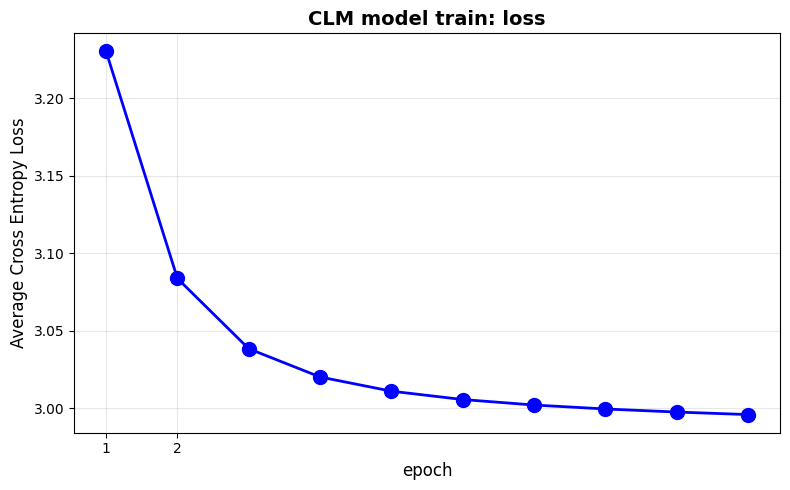


*** 학습 분석 ***
손실 감소율: 7.3%
첫 에포크 손실 (무작위 수준): 3.2302
마지막 에포크 손실 (개선됨): 2.9960


In [14]:
# 손실 변화 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history)+1), loss_history, 'bo-', linewidth=2, markersize=10)
plt.xlabel('epoch', fontsize=12)
plt.ylabel('Average Cross Entropy Loss', fontsize=12)
plt.title('CLM model train: loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks([1, 2])
plt.tight_layout()
plt.show()

print("\n*** 학습 분석 ***")
print(f"손실 감소율: {(loss_history[0] - loss_history[-1])/loss_history[0]*100:.1f}%")
print(f"첫 에포크 손실 (무작위 수준): {loss_history[0]:.4f}")
print(f"마지막 에포크 손실 (개선됨): {loss_history[-1]:.4f}")

### 결론

**핵심 배운 점:**
1. CLM = 이전 토큰 → 다음 토큰 예측 (자기감독학습)
2. Cross Entropy Loss = 정답 예측 확률로 손실 측정
3. 경사하강법 = 손실을 줄이는 방향으로 가중치 업데이트

**개선 방향 (실제 GPT 모델):**
- Embedding 레이어: 문자→벡터로 변환 ✓ (우리가 구현함)
- Attention 메커니즘: 긴 의존성 처리
- 여러 층 쌓기 (Deep network)
- 정규화 (Layer Normalization, Batch Norm)
- 수백억 개의 파라미터 사용

만약 학습률이 너무 크면? → 손실이 발산할 수 있음. 너무 작으면? → 변화가 거의 없음. 균형이 중요!

# [5교시]

## 학습 목표
- Scaling Law의 핵심 개념을 이해한다
- Kaplan Scaling Law와 Chinchilla Scaling Law의 차이를 파악한다
- 제한된 예산에서 최적의 모델 크기와 데이터양을 계산한다
- 실습 코드에서 계산되는 \(N\), \(D\), \(C\), 손실값의 의미를 해석한다

---

### 1. Scaling Laws란 무엇인가?

#### 정의
> 모델 성능, 즉 손실 \(L\)이 모델 파라미터 수 \(N\), 훈련 토큰 수 \(D\), 계산량 \(C\)에 따라 어떻게 변하는지 설명하는 경험적 관계식

Scaling Law는 "모델을 무조건 크게 만들면 된다"가 아니라, **모델 크기와 데이터양을 같은 계산 예산 안에서 어떻게 나눌 것인가**를 알려주는 기준입니다.

#### 핵심 변수

| 기호 | 의미 | 실무적 해석 |
|---|---|---|
| L | Loss, 손실 | 낮을수록 모델 예측이 좋음 |
| N | Number of parameters | 모델 파라미터 수 |
| D | Dataset tokens | 훈련에 사용한 토큰 수 |
| C | Compute budget | 학습에 투입 가능한 총 계산량 |

#### 왜 중요한가?

| 잘못된 접근 | 문제 |
|---|---|
| 모델만 크게 만든다 | 데이터가 부족하면 비효율적이며 과적합 위험이 커진다 |
| 데이터만 늘린다 | 모델이 너무 작으면 데이터를 충분히 흡수하지 못한다 |
| 예산 없이 감으로 정한다 | 같은 비용으로 더 낮은 손실을 얻을 기회를 놓친다 |

| 올바른 접근 | 이유 |
|---|---|
| 같은 예산에서 N과 D를 균형 있게 정한다 | Scaling Law가 손실을 낮추는 효율적인 비율을 제안한다 |

#### 직관적 비유
Scaling Law는 LLM 학습의 **예산 배분표**입니다. 모델은 "엔진", 데이터는 "연료", 계산량은 "총 예산"에 가깝습니다. 큰 엔진만 사고 연료를 적게 넣으면 멀리 못 가고, 연료만 많고 엔진이 작아도 속도가 나지 않습니다.

![alt text](image.png)
---

### 2. Kaplan Scaling Law (OpenAI, 2020)

#### 수식

$$
L(N, D) = a \cdot N^{-\alpha} + b \cdot D^{-\beta} + c
$$

여기서 \(a\), \(b\), \(c\)는 실험적으로 맞추는 상수이고, \(\alpha\), \(\beta\)는 모델 크기와 데이터양이 손실 감소에 얼마나 영향을 주는지 나타내는 지수입니다.

전체 손실은 모델 크기 \(N\)과 데이터양 \(D\)가 함께 결정합니다. 다만 직관을 위해 한쪽 변수만 따로 보면 다음처럼 해석할 수 있습니다.

$$
\text{모델 크기 효과} \propto N^{-0.07}
$$

$$
\text{데이터양 효과} \propto D^{-0.16}
$$

즉, 아래 두 식은 전체 손실 함수가 아니라 **각 요소가 손실을 줄이는 방향을 설명하는 단순화된 표현**입니다.

#### 해석

| 변화 | 직관적 의미 |
|---|---|
| N을 2배 증가 | 모델 용량이 커져 손실이 줄어든다 |
| N을 10배 증가 | 손실이 더 줄지만, 증가량 대비 효과는 점점 작아진다 |
| D를 2배 증가 | 더 많은 학습 사례를 보므로 일반화에 도움이 된다 |
| D를 10배 증가 | 데이터 부족으로 생기는 비효율을 크게 줄일 수 있다 |

Kaplan 관점에서는 큰 모델을 학습시키는 것이 매우 중요하게 해석되었습니다. 하지만 이후 Chinchilla 연구는 "모델을 크게 하는 것만큼 데이터도 충분히 많이 줘야 한다"는 점을 더 강하게 보여주었습니다.

#### 계산량 근사

Transformer 계열 언어 모델의 학습 계산량은 거칠게 다음처럼 근사합니다.

$$
C \approx 6ND
$$

- \(N\): 모델 파라미터 수
- \(D\): 훈련 토큰 수
- \(6\): forward/backward 계산을 포함한 경험적 근사 계수

이 식은 정확한 하드웨어 비용 계산식이 아니라, **모델 크기와 데이터양이 모두 커질수록 계산량이 곱셈으로 증가한다**는 점을 보여주는 용도입니다.

#### Kaplan의 권장 방향

일정한 계산 예산 \(C\)가 있을 때 Kaplan식 직관은 모델 크기와 데이터양을 모두 늘리되, 상대적으로 큰 모델의 중요성을 강하게 보았습니다.

$$
N \propto C^{1/2}
$$

$$
D \propto C^{1/2}
$$

실습에서는 이 관점을 단순화하여 \(N\)과 \(D\)를 비슷한 규모로 배분하는 방식으로 계산합니다.

---

### 3. Chinchilla Scaling Law (DeepMind, 2022)

#### 수식

$$
L(N, D) = E + \frac{A}{N^\alpha} + \frac{B}{D^\beta}
$$

이 수식은 손실 \(L\)이 세 부분으로 구성된다고 봅니다.

| 항 | 의미 |
|---|---|
| E | 줄일 수 없는 기본 손실 |
| 모델 크기 항 | 모델이 작아서 생기는 손실 |
| 데이터양 항 | 데이터가 부족해서 생기는 손실 |

모델 크기 항은 다음과 같습니다.

$$
\frac{A}{N^\alpha}
$$

데이터양 항은 다음과 같습니다.

$$
\frac{B}{D^\beta}
$$

모델을 키우면 모델 크기 항이 줄고, 데이터를 늘리면 데이터양 항이 줄어듭니다. 핵심은 둘 중 하나만 줄이는 것이 아니라, **같은 계산량에서 두 항을 균형 있게 줄이는 것**입니다.

#### 주요 발견

| 항목 | GPT-3식 큰 모델 접근 | Chinchilla 접근 |
|---|---:|---:|
| 파라미터 수 | 약 1,750억 개 | 약 700억 개 |
| 훈련 토큰 수 | 약 3,000억 개 | 약 1조 4,000억 개 |
| D/N 비율 | 약 1.7배 | 약 20배 |
| 해석 | 모델은 크지만 데이터가 상대적으로 부족 | 모델은 작아도 데이터를 충분히 학습 |

Chinchilla의 핵심 결론은 다음과 같습니다.

$$
D \approx 20N
$$

즉, 파라미터가 \(N\)개라면 훈련 토큰은 대략 \(20N\)개가 되도록 잡는 것이 계산 효율적이라는 뜻입니다.

#### 실습 코드 변수 해석

실습에서 `N`, `D`, `C`는 텐서라기보다 스칼라 값입니다. 하지만 모델 설계 관점에서는 다음 의미를 가집니다.

| 코드 변수 | 수학 기호 | 예시 값 | 의미 |
|---|---|---:|---|
| `model_size` | N | `7.0e+10` | 700억 파라미터 |
| `data_tokens` | D | `1.4e+12` | 1조 4,000억 토큰 |
| `compute_budget` | C | `6*N*D` | 학습 계산량 근사 |
| `loss` | L | 실습 계산값 | 낮을수록 좋은 예측 성능 |

---

### 4. Kaplan vs Chinchilla를 직관적으로 비교하기

#### 같은 계산 예산이 있을 때

| 선택지 | 모델 크기 | 데이터양 | 기대되는 문제 |
|---|---:|---:|---|
| 모델을 크게 키움 | 큼 | 부족할 수 있음 | 데이터 부족, 비효율 |
| 데이터를 많이 줌 | 너무 작을 수 있음 | 큼 | 모델 용량 부족 |
| Chinchilla식 균형 | 적정 | 적정 | 계산 예산을 더 효율적으로 사용 |

#### 시나리오

예산이 100 GPU-일이라고 가정합니다.

| 옵션 | 모델 크기 | 토큰 수 | 해석 |
|---|---:|---:|---|
| A: 큰 모델 | 1B 파라미터 | 5B 토큰 | 모델은 크지만 데이터가 부족할 수 있음 |
| B: 균형 모델 | 300M 파라미터 | 6B 토큰 | D가 N의 약 20배인 설정 |

일반적으로 옵션 B처럼 모델 크기와 데이터량의 비율을 맞추는 방식이 같은 예산에서 더 안정적입니다.

---

### 5. 실습과 실제 모델로 확인하기

#### 이론과 실습의 연결

이번 교안의 핵심 개념은 `04_ScalingLaws/실습.ipynb`에서 다음 흐름으로 확인합니다.

| 교안 개념 | 실습 매핑 |
|---|---|
| Kaplan Scaling Law | Kaplan 계수 초기화 및 손실 계산 |
| Chinchilla Scaling Law | D = 20N 비율 기반 모델/데이터 계산 |
| 계산량 근사식 | 예산별 N, D 산출 |
| Kaplan vs Chinchilla 비교 | 표와 그래프 출력 |
| 실제 LLM 분석 | GPT-2, GPT-3, Chinchilla, LLaMA 계열의 D/N 비교 |

#### 실제 LLM 사례

실습 마지막 파트는 실제 공개 LLM 사례를 사용해 D/N 비율을 검증합니다.

| 모델 | 파라미터 N | 토큰 D | D/N |
|---|---:|---:|---:|
| GPT-2 | `1.5e+9` | `4.0e+10` | 26.7배 |
| GPT-3 | `1.75e+11` | `3.0e+11` | 1.7배 |
| Chinchilla | `7.0e+10` | `1.4e+12` | 20.0배 |
| LLaMA-65B | `6.5e+10` | `1.4e+12` | 21.5배 |

#### 실습 출력 표기 읽는 법

실습 출력에서 자주 보이는 표기법은 다음처럼 해석합니다.

| 출력 기호 | 의미 | 읽는 법 |
|---|---|---|
| `1.75e+11` | 1.75 곱하기 10의 11제곱 | 1,750억 |
| `1.40e+12` | 1.40 곱하기 10의 12제곱 | 1조 4,000억 |
| `20.0x` | D/N = 20 | 파라미터 1개당 토큰 20개 |
| `loss` | L | 낮을수록 좋음 |
| `-1.4%` | 비교 기준 대비 차이 | 실습의 단순화된 가정에서 나온 상대 차이 |

#### 실패 사례로 이해하기

Scaling Law를 잘못 적용하면 다음 문제가 생깁니다.

| 실패 사례 | 원인 | 결과 |
|---|---|---|
| N만 크게 함 | 데이터 D 부족 | 학습 효율 저하, 과적합 위험 |
| D만 크게 함 | 모델 N 부족 | 데이터의 패턴을 충분히 흡수하지 못함 |
| C를 과소평가 | 실제 하드웨어 효율 무시 | 학습 시간과 비용 초과 |
| 데이터 품질 무시 | 낮은 품질의 토큰 증가 | 토큰 수는 많지만 성능 향상 제한 |

---

### In-context Learning
- 모델이 가중치를 바꾸지 않고 프롬프트에 예시를 추가해서 새로운 태스크를 수행하는 방식
- 새로운 태스크가 나타나면
    - 몇 줄의 예시 작성
    - 즉시 사용

### 기존 방식 - Fine turning
- 새로운 태스크가 나타나면
    - 데이터 수집 및 레이블링
    - 모델 재학습(며칠~주)
    - 배포

### Zero-shot vs One-shot VS Few-shot
- Zero-shot : 예시가 없음
- "다음 영화 리뷰의 감성을 분석하세요.
- 리뷰 : '이 영화는 정말 멋있었어!'
- 감성:"

- --> "긍정"

- 특징
    - 인스트럭션만으로 수행
    - 작은모델은 거의 작동안함
    - 큰 모델은 기본 테스크는 수행 가능

### One-shot : 1개 예시
```
프롬프트:
"다음 영화 리뷰의 감성을 분석하세요.

리뷰:'영화가 정말 재미있었어요!'
감성: 긍정

리뷰: '이 영화는 멋있었어!'
감성"
```
- 출력 : 긍정

- 특징:
    - 1개 예시제공으로 패턴 이해
    - 성능 급상승
    - 큰 모델에서 특히 효과적

### Few-shot(여러 예시)
- 특징
    - 다양한 예시로 강화
    - 최고의 성능
    - 일반적으로는 3 ~5개 최적

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [16]:
train_data = [
    ("영화가 정말 재미있다", "긍정"),
    ("최악의 영화였다", "부정"),
    ("배우 연기가 훌륭했다", "긍정"),
    ("스토리가 너무 지루했다", "부정"),
    ("정말 감동적이었다", "긍정"),
    ("시간 낭비였다", "부정"),
]

test_reviews = [
    "이 영화는 정말 멋있었어!",
    "완전히 실망했다",
    "그냥 볼만했다"
]

In [17]:
# zero-shot prompt
zero_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요

리뷰:'이 영화는 정말 멋있었어!'
감성:
'''
one_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요.

리뷰: "영화가 정말 재미있었어요!"
감성: 긍정

리뷰: "이 영화는 정말 멋있었어!"
감성:
'''
few_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요.

리뷰: "영화가 정말 재미있었어요!"
감성: 긍정

리뷰: "완전히 실망했어요."
감성: 부정

리뷰: "그런대로 괜찮네요."
감성: 중립

리뷰: "이 영화는 정말 멋있었어!"
감성:
'''

# [6교시]

In [18]:
%pip install --upgrade transformers
%pip install --upgrade torch

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [19]:
from transformers import AutoModelForCausalLM, AutoTokenizer
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

In [20]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
print(model)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6903.22it/s]


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [21]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
print(model)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 5957.61it/s]


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [22]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
def generate_sentiment(prompt, max_new_tokens=20):
    message = [
        {
            "role" : "system",
            'content' : '너는 영화 리뷰 감성을 긍정, 부정, 중립중 하나로만 분류하는 분류기입니다.'
        },
        {
            'role':'user',
            'content':prompt
        }
    ]
    text = tokenizer.apply_chat_template(
        message,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text,return_tensors='pt').to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = output_ids[0][ inputs['input_ids'].shape[-1] : ]
    return tokenizer.decode(generated_ids,skip_special_tokens=True).strip()

In [23]:
results = {
    'Zero-shot' : generate_sentiment(zero_shot_prompt),
    'One-shot' : generate_sentiment(one_shot_prompt),
    'Few-shot' : generate_sentiment(few_shot_prompt),
}
for key,value in results.items():
    print(key,value)

Zero-shot 감성: 부정

이 리뷰에서 "이 영화는 정말 멋있었어
One-shot 감성: 부정
Few-shot 감성: 긍정


# [7교시]

In [24]:
!echo $env:OPENAPI_API_KEY

$env:OPENAPI_API_KEY


In [33]:
import os
import getpass
from openai import OpenAI
os.environ['OPENAPI_API_KEY']
openai_client = OpenAI(api_key=os.environ['OPENAPI_API_KEY'])

In [35]:
openai_model = 'gpt-5.2'

In [ ]:
def call_openai_sentiment(prompt, max_output_tokens=30):
    response = openai_client.responses.create(
        model=openai_model,
        instructions=(
            "너는 영화 리뷰감성을 분류하는 분류기야"
            "반드시 긍정 부정 중립중 하나의 한국어 라벨만 출력해"
            "설명 번호 영어 번역은 출력하지 마"
        ),        
        input=prompt,
        max_output_tokens=max_output_tokens
    )
    return response.output_text.strip()

In [38]:
zero_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요

리뷰:'이 영화는 정말 멋있었어!'
감성:
'''
one_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요.

리뷰: "영화가 정말 재미있었어요!"
감성: 긍정

리뷰: "이 영화는 정말 멋있었어!"
감성:
'''
few_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요.

리뷰: "영화가 정말 재미있었어요!"
감성: 긍정

리뷰: "완전히 실망했어요."
감성: 부정

리뷰: "그런대로 괜찮네요."
감성: 중립

리뷰: "이 영화는 정말 멋있었어!"
감성:
'''

In [39]:
openai_results = {
    'zero-shot':call_openai_sentiment(zero_shot_prompt),
    'one-shot':call_openai_sentiment(one_shot_prompt),
    'few-shot':call_openai_sentiment(few_shot_prompt),
}
openai_results

{'zero-shot': '긍정', 'one-shot': '긍정', 'few-shot': '긍정'}

In [40]:
'''
제로샷
    예시 : 0
    장점 : 빠름
    단점 : 정확도 낮음
one-shot:
    예시 : 1
    장점 : 패턴 이해 가능
    단점 : 예시 품질 영향 큼
few-shot:
    예시 : 3~5
    장점 : 높은성능
    단점 : 프롬프트 길어짐
'''

'\n제로샷\n    예시 : 0\n    장점 : 빠름\n    단점 : 정확도 낮음\none-shot:\n    예시 : 1\n    장점 : 패턴 이해 가능\n    단점 : 예시 품질 영향 큼\nfew-shot:\n    예시 : 3~5\n    장점 : 높은성능\n    단점 : 프롬프트 길어짐\n'

### 명확한 인스트럭션
- bad
    - 감정을 찾아줘
- good
    - 다음 영화 리뷰의 감정을 긍정/부정/중립 중 하나로 분류하세요 응답은 감정 단어 하나만 출력하세요

### 일관된 포멧
- 리뷰1 : ...
- 감정 : 긍정

- 리뷰2 : ...
- 감정 : 부정

- 리뷰 : ...
- 감정 : 긍정

- 리뷰 : ...
- 감정 : 부정

### 다양한 예시 : 균형잡히게
- 예시 1 : "좋아" ->긍정
- 예시 1 : "최고야" ->긍정
- 예시 1 : "훌륭해" ->긍정

- 예시 1 : "좋아" ->긍정
- 예시 1 : "싫어" ->부정
- 예시 1 : "그럭저럭" ->중립

### 예시의 순서효과
- 긍정1, 긍정2, 부정, 중립 -> 모델이 긍정을 과도하게 예측 과적합 상태

- 긍정,부정,중립 -> 균형있게 학습

### 추천
- 클래스별 균형
- 어려운 경우부터 시작(모델이 주의집중)
- 같은 클래스 반복 피하기
- 무작위 섞기보다 신중하게 배열

### 전략
- 다양성 극대화
    - 선택기준:
        - 각 클래스를 대표하는 명확한 사례
        - 경계 사례 포함(모호한 케이스)
        - 도메일 특화 어휘 포함
- 어려움 레벨 고려
    - Easy : '이 영화 최고야! (명확한 긍정)
    - Midium : '그런대로 나쁘지 않네'(부정 + 약한표현)
    - Hard : .... (도메인특화, 뉘양스 중요)

    - 프롬프트 : Easy->Medium->Hard 순서


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

In [42]:
# 법률 문서 조항 데이터
legal_data = [
    {
        "text": "본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.",
        "category": "기간",
        "difficulty": "easy"
    },
    {
        "text": "계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.",
        "category": "위약금",
        "difficulty": "medium"
    },
    {
        "text": "갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.",
        "category": "책임제한",
        "difficulty": "medium"
    },
    {
        "text": "본 계약에 명시되지 않은 사항에 대해서는 관계 법령을 준용한다.",
        "category": "준거법",
        "difficulty": "hard"
    },
    {
        "text": "이용자는 언제든지 7일 이전 통지로 본 계약을 해지할 수 있다.",
        "category": "해지",
        "difficulty": "easy"
    },
    {
        "text": "당사자 간의 분쟁이 발생할 경우 서울중앙지방법원을 관할 법원으로 한다.",
        "category": "관할법원",
        "difficulty": "hard"
    },
]

test_data = [
    {"text": "본 서비스는 2024년 1월부터 시작된다.", "category": "기간"},
    {"text": "계약 위반 시 연 10%의 위약금을 청구할 수 있다.", "category": "위약금"},
    {"text": "본사는 서비스 중단에 대해 책임지지 않는다.", "category": "책임제한"},
    {"text": "분쟁은 중재법에 따라 처리된다.", "category": "준거법"},
]

print(f"훈련 데이터: {len(legal_data)}개")
for i, d in enumerate(legal_data, 1):
    print(f"  {i}. [{d['category']:8}] {d['text'][:40]}...")

print(f"\n테스트 데이터: {len(test_data)}개")
for i, d in enumerate(test_data, 1):
    print(f"  {i}. {d['text'][:50]}...")

훈련 데이터: 6개
  1. [기간      ] 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일...
  2. [위약금     ] 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 ...
  3. [책임제한    ] 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다...
  4. [준거법     ] 본 계약에 명시되지 않은 사항에 대해서는 관계 법령을 준용한다....
  5. [해지      ] 이용자는 언제든지 7일 이전 통지로 본 계약을 해지할 수 있다....
  6. [관할법원    ] 당사자 간의 분쟁이 발생할 경우 서울중앙지방법원을 관할 법원으로 한다....

테스트 데이터: 4개
  1. 본 서비스는 2024년 1월부터 시작된다....
  2. 계약 위반 시 연 10%의 위약금을 청구할 수 있다....
  3. 본사는 서비스 중단에 대해 책임지지 않는다....
  4. 분쟁은 중재법에 따라 처리된다....


In [ ]:
class PromptOptimizer:
    """프롬프트 최적화 클래스"""
    
    def __init__(self):
        self.category_map = {
            "기간": ["시간", "기간", "날짜", "년도", "일자"],
            "위약금": ["위약금", "손해배상", "페널티", "과태료", "위반"],
            "책임제한": ["책임", "담당", "책임제한", "면책", "책임지지"],
            "준거법": ["법령", "준거법", "법률", "규정", "법"],
            "해지": ["해지", "종료", "종료", "폐기", "중단"],
            "관할법원": ["법원", "중재", "소송", "분쟁", "관할"],
        }
    
    def classify_simple(self, text):
        """키워드 기반 분류"""
        text_lower = text.lower()
        scores = {}
        
        for category, keywords in self.category_map.items():
            score = sum(1 for kw in keywords if kw in text_lower)
            scores[category] = score
        
        if max(scores.values()) == 0:
            return "기타"
        
        return max(scores, key=scores.get)

optimizer = PromptOptimizer()
print("프롬프트 최적화 클래스 초기화 완료")

프롬프트 최적화 클래스 초기화 완료


In [46]:
def create_prompt(examples, order="original"):
    """프롬프트 생성"""
    
    if order == "random":
        examples = list(examples)
        np.random.shuffle(examples)
    elif order == "difficulty":
        # 어려움 순서: easy → medium → hard
        difficulty_order = {"easy": 0, "medium": 1, "hard": 2}
        examples = sorted(examples, key=lambda x: difficulty_order.get(x.get("difficulty", "easy"), 0))
    elif order == "balanced":
        # 각 카테고리가 고르게 분포
        by_category = {}
        for ex in examples:
            cat = ex["category"]
            if cat not in by_category:
                by_category[cat] = []
            by_category[cat].append(ex)
        
        examples = []
        max_len = max(len(v) for v in by_category.values())
        for i in range(max_len):
            for cat in by_category:
                if i < len(by_category[cat]):
                    examples.append(by_category[cat][i])
    
    prompt = """다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

"""
    
    for ex in examples:
        prompt += f"조항: {ex['text']}\n"
        prompt += f"카테고리: {ex['category']}\n\n"
    
    return prompt, examples

# 4가지 순서로 프롬프트 생성
orders = ["original", "random", "difficulty", "balanced"]

for order in orders:
    prompt, ex_order = create_prompt(legal_data[:3], order=order)
    print(f"\n{'='*60}")
    print(f"[순서: {order.upper()}]")
    print(f"{'='*60}")
    print(prompt[:300] + "...")
    print(f"예시 순서: {[ex['category'] for ex in ex_order]}")


[순서: ORIGINAL]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

조항: 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.
카테고리: 기간

조항: 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.
카테고리: 위약금

조항: 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.
카테고리: 책임제한

...
예시 순서: ['기간', '위약금', '책임제한']

[순서: RANDOM]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

조항: 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.
카테고리: 기간

조항: 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.
카테고리: 위약금

조항: 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.
카테고리: 책임제한

...
예시 순서: ['기간', '위약금', '책임제한']

[순서: DIFFICULTY]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

조항: 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.
카테고리: 기간

조항: 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.
카테고리: 위약금

조항: 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.
카테고리: 책임제한

...
예시 순서: ['기간', '위약금', '책임제한']

[순서: BALANCED]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간,

In [47]:
def evaluate_prompt(examples, test_data, optimizer):
    """프롬프트 평가"""
    
    # 테스트 데이터 분류
    predictions = []
    for test in test_data:
        pred = optimizer.classify_simple(test['text'])
        predictions.append(pred)
    
    # 정확도 계산
    correct = sum(1 for pred, test in zip(predictions, test_data) if pred == test['category'])
    accuracy = correct / len(test_data)
    
    return accuracy, predictions

# 각 순서별 성능 평가
results = []

for order in orders:
    prompt, ex_order = create_prompt(legal_data[:4], order=order)
    accuracy, preds = evaluate_prompt(ex_order, test_data, optimizer)
    
    results.append({
        '순서': order.upper(),
        '예시배열': ' → '.join([ex['category'] for ex in ex_order]),
        '정확도': f'{accuracy:.0%}',
        '정확한수': f'{int(accuracy * len(test_data))}/{len(test_data)}'
    })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("[프롬프트 순서 효과 분석]")
print("="*80)
print(results_df.to_string(index=False))


[프롬프트 순서 효과 분석]
        순서                  예시배열 정확도 정확한수
  ORIGINAL 기간 → 위약금 → 책임제한 → 준거법 50%  2/4
    RANDOM 책임제한 → 준거법 → 위약금 → 기간 50%  2/4
DIFFICULTY 기간 → 위약금 → 책임제한 → 준거법 50%  2/4
  BALANCED 기간 → 위약금 → 책임제한 → 준거법 50%  2/4


In [49]:
def create_optimized_prompt(examples):
    """최적화된 프롬프트 생성"""
    
    prompt = """당신은 법률 문서 분석 전문가입니다.
다음 법률 조항의 카테고리를 정확히 분류하세요.

## 카테고리 정의
- 기간: 계약의 유효 기간, 시작/종료 날짜
- 위약금: 계약 위반 시 페널티, 손해배상
- 책임제한: 당사자의 책임 범위 제한, 면책 조항
- 준거법: 계약 분쟁 시 적용 법령, 법률 준용
- 해지: 계약 해지 조건, 해지 절차
- 관할법원: 분쟁 해결 절차, 소송 관할권

## 분류 예시
"""
    
    for ex in examples:
        prompt += f"조항: \"{ex['text']}\"\n"
        prompt += f"→ 카테고리: {ex['category']}\n\n"
    
    prompt += "## 분류할 조항\n"
    prompt += "조항: \"{text}\"\n"
    prompt += "→ 카테고리: "
    
    return prompt

# 최적 프롬프트 생성
optimized_prompt = create_optimized_prompt(legal_data[:3])
print("\n" + "="*60)
print("[최적화된 프롬프트 템플릿]")
print("="*60)
print(optimized_prompt)

print("\n\n최적화 포인트:")
print("  1. 명확한 카테고리 정의 제공")
print("  2. 일관된 포맷 사용")
print("  3. 다양한 예시 포함")
print("  4. 이해하기 쉬운 언어")
print("  5. 출력 형식 명시")


[최적화된 프롬프트 템플릿]
당신은 법률 문서 분석 전문가입니다.
다음 법률 조항의 카테고리를 정확히 분류하세요.

## 카테고리 정의
- 기간: 계약의 유효 기간, 시작/종료 날짜
- 위약금: 계약 위반 시 페널티, 손해배상
- 책임제한: 당사자의 책임 범위 제한, 면책 조항
- 준거법: 계약 분쟁 시 적용 법령, 법률 준용
- 해지: 계약 해지 조건, 해지 절차
- 관할법원: 분쟁 해결 절차, 소송 관할권

## 분류 예시
조항: "본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다."
→ 카테고리: 기간

조항: "계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다."
→ 카테고리: 위약금

조항: "갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다."
→ 카테고리: 책임제한

## 분류할 조항
조항: "{text}"
→ 카테고리: 


최적화 포인트:
  1. 명확한 카테고리 정의 제공
  2. 일관된 포맷 사용
  3. 다양한 예시 포함
  4. 이해하기 쉬운 언어
  5. 출력 형식 명시


In [50]:
# 허깅페이스 모델로 최적화 프롬프트 실행
# 입력 : 최적화된 프롬프트 + 테스트 조항
# 출력 : 기간 위약금 책임제한 준거법 해지 관할법원 중 하나

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
).to(device)
categories = ['기간', '위약금', '책임제한', '준거법', '해지', '관할법원']

def normalize_category(text):
    """모델 출력에서 카테고리명만 추출"""
    for category in categories:
        if category in text:
            return category
    return text.strip()

def classify_with_huggingface(clause):
    prompt = optimized_prompt.format(text=clause)
    messages = [
        {
            "role": "system",
            "content": "너는 법률 문서 조항을 정해진 카테고리 중 하나로만 분류하는 전문가야. 설명 없이 카테고리명만 출력해."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    chat_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(chat_prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return normalize_category(raw_output), raw_output

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6155.92it/s]


# [8교시]

In [51]:
test_data

[{'text': '본 서비스는 2024년 1월부터 시작된다.', 'category': '기간'},
 {'text': '계약 위반 시 연 10%의 위약금을 청구할 수 있다.', 'category': '위약금'},
 {'text': '본사는 서비스 중단에 대해 책임지지 않는다.', 'category': '책임제한'},
 {'text': '분쟁은 중재법에 따라 처리된다.', 'category': '준거법'}]

In [54]:
print(optimized_prompt.format(text=test_data[0]['text']))

당신은 법률 문서 분석 전문가입니다.
다음 법률 조항의 카테고리를 정확히 분류하세요.

## 카테고리 정의
- 기간: 계약의 유효 기간, 시작/종료 날짜
- 위약금: 계약 위반 시 페널티, 손해배상
- 책임제한: 당사자의 책임 범위 제한, 면책 조항
- 준거법: 계약 분쟁 시 적용 법령, 법률 준용
- 해지: 계약 해지 조건, 해지 절차
- 관할법원: 분쟁 해결 절차, 소송 관할권

## 분류 예시
조항: "본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다."
→ 카테고리: 기간

조항: "계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다."
→ 카테고리: 위약금

조항: "갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다."
→ 카테고리: 책임제한

## 분류할 조항
조항: "본 서비스는 2024년 1월부터 시작된다."
→ 카테고리: 


In [52]:
predictions = []
for item in test_data:
    prediction, raw_output =  classify_with_huggingface(item['text'])
    predictions.append({
        '조항' : item['text'],
        '정답' : item['category'],
        '예측' : prediction,
        '원본출력':raw_output,
        '정답여부' : prediction == item['category']
    })
result_df = pd.DataFrame(predictions)
accuracy = result_df['정답여부'].mean()
print('정확도',accuracy)

정확도 0.5


In [53]:
predictions

[{'조항': '본 서비스는 2024년 1월부터 시작된다.',
  '정답': '기간',
  '예측': '기간',
  '원본출력': '기간',
  '정답여부': True},
 {'조항': '계약 위반 시 연 10%의 위약금을 청구할 수 있다.',
  '정답': '위약금',
  '예측': '위약금',
  '원본출력': '위약금',
  '정답여부': True},
 {'조항': '본사는 서비스 중단에 대해 책임지지 않는다.',
  '정답': '책임제한',
  '예측': '관할법원',
  '원본출력': '카테고리: 관할법원',
  '정답여부': False},
 {'조항': '분쟁은 중재법에 따라 처리된다.',
  '정답': '준거법',
  '예측': '해지',
  '원본출력': '해지',
  '정답여부': False}]

In [55]:
# openai

import os
import getpass
from openai import OpenAI
openai_client = OpenAI(api_key=os.environ['OPENAPI_API_KEY'])
openai_model = 'gpt-5.2'

def call_openai_sentiment(text, max_output_tokens=30):
    response = openai_client.responses.create(
        model=openai_model,
        instructions=(
            "너는 영화 리뷰감성을 분류하는 분류기야"
            "반드시 긍정 부정 중립중 하나의 한국어 라벨만 출력해"
            "설명 번호 영어 번역은 출력하지 마"
        ),        
        input=optimized_prompt.format(text=text),
        max_output_tokens=max_output_tokens
    )
    return response.output_text.strip()

for item in test_data:    
    print(call_openai_sentiment(item['text']), item['category']   )

중립 기간
부정 위약금
중립 책임제한
중립 준거법
